<a href="https://colab.research.google.com/github/tabassumanchal619-sys/CSVMLProject/blob/main/adasyn%2C_main_model_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original shape: (1470, 35)
After cleaning: (1470, 35)

📊 Variance & uniqueness check for non-informative attributes:
EmployeeCount   | Unique values:   1 | Variance: 0.0
Over18          | Unique values:   1 | Variance: N/A
StandardHours   | Unique values:   1 | Variance: 0.0
EmployeeNumber  | Unique values: 1470 | Variance: 362433.2997485447
After dropping unnecessary columns: (1470, 31)

Train shape: (1102, 30)
Test shape : (368, 30)

Class distribution before ADASYN:
 Attrition
0    924
1    178
Name: count, dtype: int64

Class distribution after ADASYN:
 Attrition
0    924
1    849
Name: count, dtype: int64

🔍 Information Gain (Top 15 features):
Age                         0.343317
TotalWorkingYears           0.341141
DistanceFromHome            0.320620
YearsAtCompany              0.317836
YearsWithCurrManager        0.315927
PercentSalaryHike           0.314486
HourlyRate                  0.291609
YearsInCurrentRole          0.280404
NumCompaniesWorked          0.256399
JobRole   

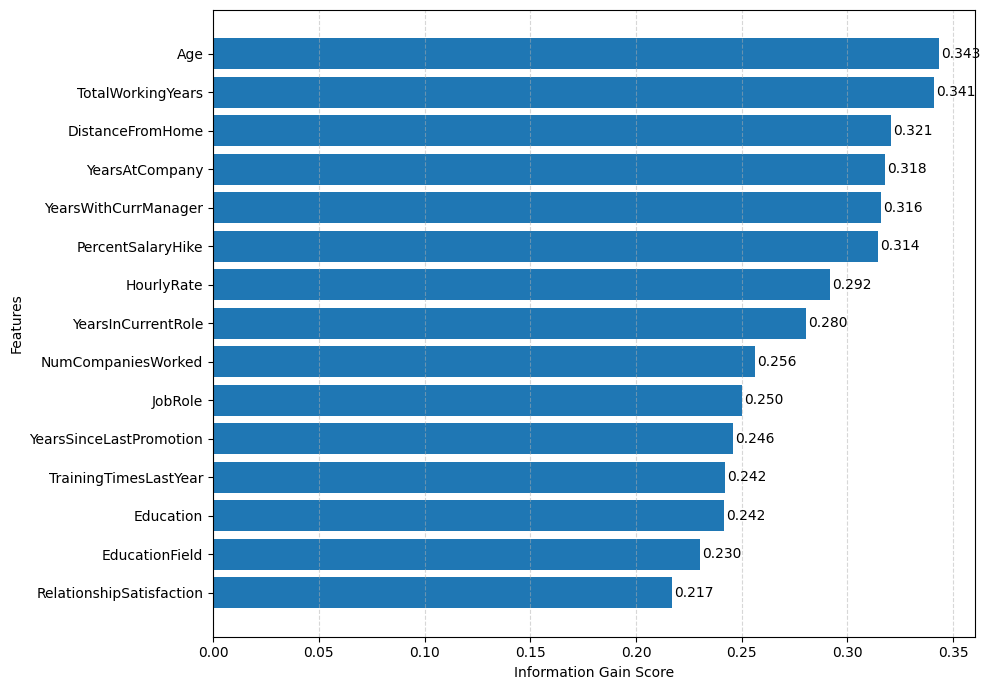


✅ Graph saved as: information_gain_top15.png

✅ Leakage-free preprocessing with ADASYN complete!


In [ ]:
# ===============================================
# 📌 IBM HR ATTRITION — LEAKAGE-FREE PREPROCESSING
# Uses ADASYN (Adaptive Synthetic Sampling)
# ===============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import ADASYN

RND = 42

# --------------------------------------------------
# 1️⃣ Load Dataset
# --------------------------------------------------
df = pd.read_csv("/content/dataset.csv")
print("Original shape:", df.shape)

# --------------------------------------------------
# 2️⃣ Move Attrition to last column (WEKA style)
# --------------------------------------------------
attr = df.pop("Attrition")
df["Attrition"] = attr

# --------------------------------------------------
# 3️⃣ Remove duplicates & missing values
# --------------------------------------------------
df = df.drop_duplicates()
df = df.dropna()
print("After cleaning:", df.shape)

# --------------------------------------------------
# 🔍 Explainable check: Variance & uniqueness analysis
# --------------------------------------------------
candidate_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]

print("\n📊 Variance & uniqueness check for non-informative attributes:")
for col in candidate_cols:
    unique_vals = df[col].nunique()
    variance = df[col].var() if pd.api.types.is_numeric_dtype(df[col]) else "N/A"
    print(f"{col:15s} | Unique values: {unique_vals:3d} | Variance: {variance}")

# --------------------------------------------------
# 4️⃣ Drop non-informative columns
# --------------------------------------------------
df = df.drop(columns=candidate_cols)
print("After dropping unnecessary columns:", df.shape)

# --------------------------------------------------
# 5️⃣ Encode categorical features (Ordinal — WEKA equivalent)
# NOTE: ADASYN requires numeric features → ordinal encoding is acceptable
# --------------------------------------------------
label_encoders = {}
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols.remove("Attrition")

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target variable
le_y = LabelEncoder()
df["Attrition"] = le_y.fit_transform(df["Attrition"])  # Yes=1, No=0

# --------------------------------------------------
# 6️⃣ Train–Test Split (CRITICAL: before scaling / ADASYN)
# --------------------------------------------------
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RND,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# --------------------------------------------------
# 7️⃣ Feature Scaling (fit on TRAIN only)
# --------------------------------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --------------------------------------------------
# 8️⃣ Class Balancing — ADASYN (TRAIN ONLY)
# Adaptive synthetic sampling focuses on hard-to-learn samples
# --------------------------------------------------
adasyn = ADASYN(
    sampling_strategy=0.9,
    n_neighbors=5,
    random_state=RND
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_train_scaled, y_train)

print("\nClass distribution before ADASYN:\n", y_train.value_counts())
print("\nClass distribution after ADASYN:\n", pd.Series(y_train_bal).value_counts())

# --------------------------------------------------
# 9️⃣ Feature Selection — Information Gain (TRAIN ONLY)
# WEKA InfoGainAttributeEval equivalent
# --------------------------------------------------
# 9️⃣ Feature Selection — Information Gain (TRAIN ONLY)
# WEKA InfoGainAttributeEval equivalent
# --------------------------------------------------

import matplotlib.pyplot as plt

# Compute Information Gain
mi = mutual_info_classif(
    X_train_bal,
    y_train_bal,
    random_state=RND
)

# Convert to Series
mi_scores = pd.Series(
    mi,
    index=X.columns
).sort_values(ascending=False)

# Print Top Features
print("\n🔍 Information Gain (Top 15 features):")
print(mi_scores.head(15))

# --------------------------------------------------
# 📊 Plot Top 15 Features
# --------------------------------------------------

top_features = mi_scores.head(15).sort_values()

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features.index,
    top_features.values
)

# Add score labels
for i, v in enumerate(top_features.values):
    plt.text(
        v + 0.001,
        i,
        f"{v:.3f}",
        va='center'
    )

plt.xlabel("Information Gain Score")
plt.ylabel("Features")


plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

# --------------------------------------------------
# 💾 Save Graph
# --------------------------------------------------

plt.savefig(
    "information_gain_top15.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("\n✅ Graph saved as: information_gain_top15.png")

# --------------------------------------------------
# 🔟 Final outputs for modeling
# --------------------------------------------------
X_bal = X_train_bal          # balanced training features
y_bal = y_train_bal          # balanced training labels

X_test_final = X_test_scaled # untouched test features
y_test_final = y_test.values

print("\n✅ Leakage-free preprocessing with ADASYN complete!")


In [ ]:
# ============================================================
# 📌 STACKING ENSEMBLE (AFTER PREPROCESSING)
# Base learners: CatBoost, SVM (PUK), RandomForest, ExtraTreesClassifer
# Meta learner: Logistic Regression
# Uses: X_bal, y_bal from preprocessing
# ============================================================

import sys, subprocess, warnings
warnings.filterwarnings("ignore")

# ---------------------------
# helper to pip-install packages if missing
# ---------------------------
def _pip_install(pkg):
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for pkg in ["catboost", "xgboost", "joblib"]:
    _pip_install(pkg)

# ---------------------------
# imports
# ---------------------------
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.metrics.pairwise import euclidean_distances

from catboost import CatBoostClassifier

RND = 42
N_FOLDS = 5

# ============================================================
# Precondition
# ============================================================
try:
    _ = X_bal, y_bal
except Exception:
    raise RuntimeError("X_bal and y_bal must exist (run preprocessing first).")

# ============================================================
# 1️⃣ Train / Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=RND, stratify=y_bal
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

# ============================================================
# 2️⃣ SVM with PUK Kernel
# ============================================================
pair_dists = euclidean_distances(X_train, X_train)
iu = np.triu_indices(pair_dists.shape[0], k=1)
nonzero_dists = pair_dists[iu]

PUK_SIGMA = float(np.median(nonzero_dists)) if nonzero_dists.size > 0 else 1.0
PUK_SIGMA = max(PUK_SIGMA, 1.0)
PUK_OMEGA = 1.0

print(f"PUK kernel params: sigma={PUK_SIGMA:.6f}, omega={PUK_OMEGA}")

def puk_kernel(X, Y):
    c = 2.0 * np.sqrt(2.0 ** (1.0 / PUK_OMEGA) - 1.0)
    d = euclidean_distances(X, Y)
    return (1.0 + ((c * d / PUK_SIGMA) ** 2)) ** (-PUK_OMEGA)

svm_model = SVC(
    C=2.0,
    kernel=puk_kernel,
    probability=True,
    random_state=RND
)

# ============================================================
# 3️⃣ Base Models
# ============================================================
base_models = {
    "catboost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.06,
        depth=6,
        random_state=RND,
        verbose=0,
        loss_function="Logloss"
    ),
    "svm": svm_model,

    "rf": RandomForestClassifier(
        n_estimators=680,
    random_state=RND,
    n_jobs=-1
    ),
    "etc": ExtraTreesClassifier(
        n_estimators=500,
        random_state=RND,
        n_jobs=-1
    )
}

# ============================================================
# 4️⃣ OOF Containers
# ============================================================
n_train, n_test = X_train.shape[0], X_test.shape[0]
n_base = len(base_models)

oof_train = np.zeros((n_train, n_base))
oof_test  = np.zeros((n_test,  n_base))

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RND
)

# ============================================================
# 5️⃣ Generate OOF Predictions
# ============================================================
for col_idx, (name, model) in enumerate(base_models.items()):
    print(f"\n--- Base model: {name} ---")

    test_preds_folds = np.zeros((N_FOLDS, n_test))
    oof_preds = np.zeros(n_train)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f" Fold {fold+1}/{N_FOLDS}")

        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        oof_preds[val_idx] = fold_model.predict_proba(X_val)[:, 1]
        test_preds_folds[fold] = fold_model.predict_proba(X_test)[:, 1]

    oof_train[:, col_idx] = oof_preds
    oof_test[:, col_idx]  = test_preds_folds.mean(axis=0)

    final_model = clone(model)
    final_model.fit(X_train, y_train)
    joblib.dump(final_model, f"base_{name}_fullmodel.joblib")

# ============================================================
# 5.1️⃣ Base Model Performance
# ============================================================
print("\n--- Base Model Test Performance ---")
for name in base_models:
    mdl = joblib.load(f"base_{name}_fullmodel.joblib")
    p = mdl.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    print(f"{name:10s} | Acc: {accuracy_score(y_test, pred):.4f} | ROC AUC: {roc_auc_score(y_test, p):.4f}")

# ============================================================
# 6️⃣  META-LEARNER (Logistic Regression)
# ============================================================
meta_clf = LogisticRegression(max_iter=1500, random_state=RND)
meta_clf.fit(oof_train, y_train)

joblib.dump(meta_clf, "stack_meta_logistic.joblib")
print("\nMeta learner (Logistic Regression) trained.")

# ============================================================
# 7️⃣ Final Evaluation
# ============================================================
meta_proba = meta_clf.predict_proba(oof_test)[:, 1]
meta_pred  = (meta_proba >= 0.5).astype(int)

print("\n======== STACKED MODEL PERFORMANCE ========")
print("Accuracy:", accuracy_score(y_test, meta_pred))
print("ROC AUC :", roc_auc_score(y_test, meta_proba))
print("\nClassification Report:\n", classification_report(y_test, meta_pred, digits=4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, meta_pred))

print("\nDone — Pure stacking with Logistic Regression meta-learner.")


Train shape: (1418, 30)
Test shape : (355, 30)
PUK kernel params: sigma=2.187266, omega=1.0

--- Base model: catboost ---
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

--- Base model: svm ---
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

--- Base model: rf ---
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

--- Base model: etc ---
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

--- Base Model Test Performance ---
catboost   | Acc: 0.9465 | ROC AUC: 0.9831
svm        | Acc: 0.9775 | ROC AUC: 0.9980
rf         | Acc: 0.9408 | ROC AUC: 0.9814
etc        | Acc: 0.9606 | ROC AUC: 0.9949

Meta learner (Logistic Regression) trained.

======== STACKED MODEL PERFORMANCE ========
Accuracy: 0.9802816901408451
ROC AUC : 0.9976152623211447

Classification Report:
               precision    recall  f1-score   support

           0     0.9837    0.9784    0.9810       185
           1     0.9766    0.9824    0.9795       170

    accuracy                         0.9803       355
   m


================ SHAP EXPLANATION ================

Generating SHAP Bar Plot...


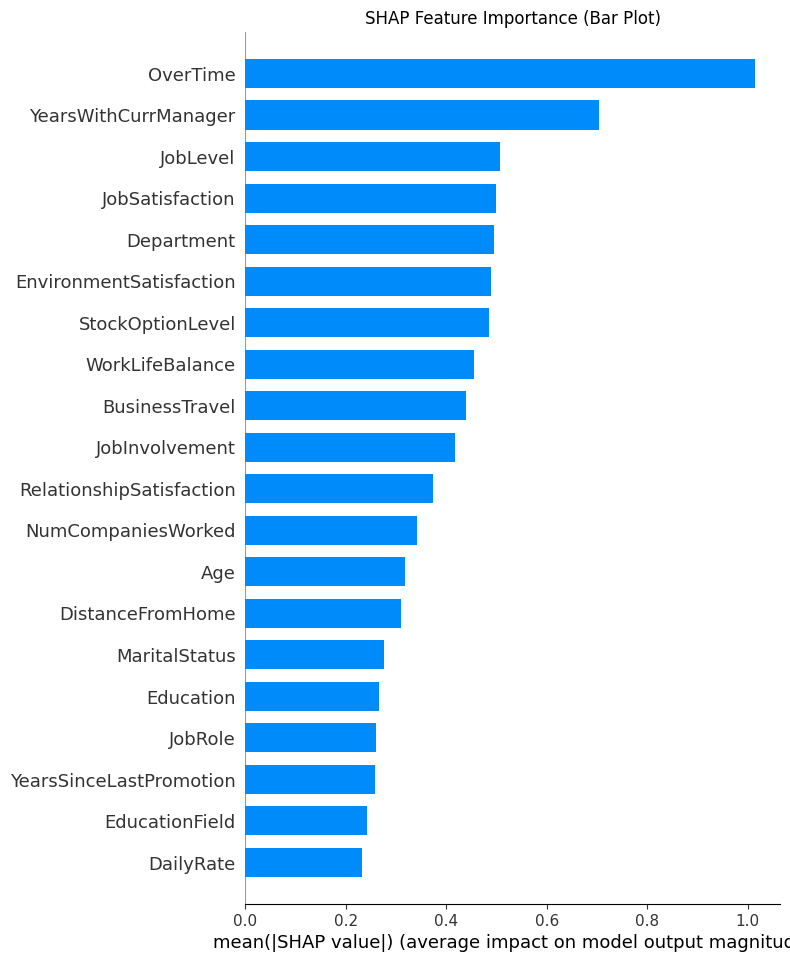


Generating SHAP Beeswarm Plot...


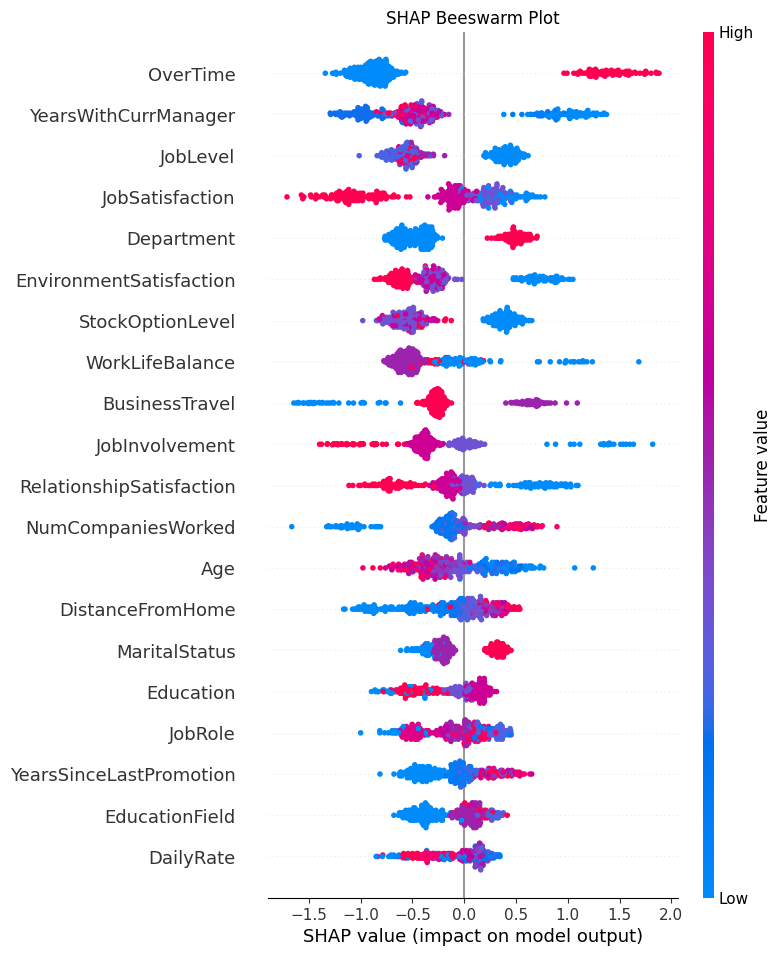


Generating SHAP Waterfall Plot...


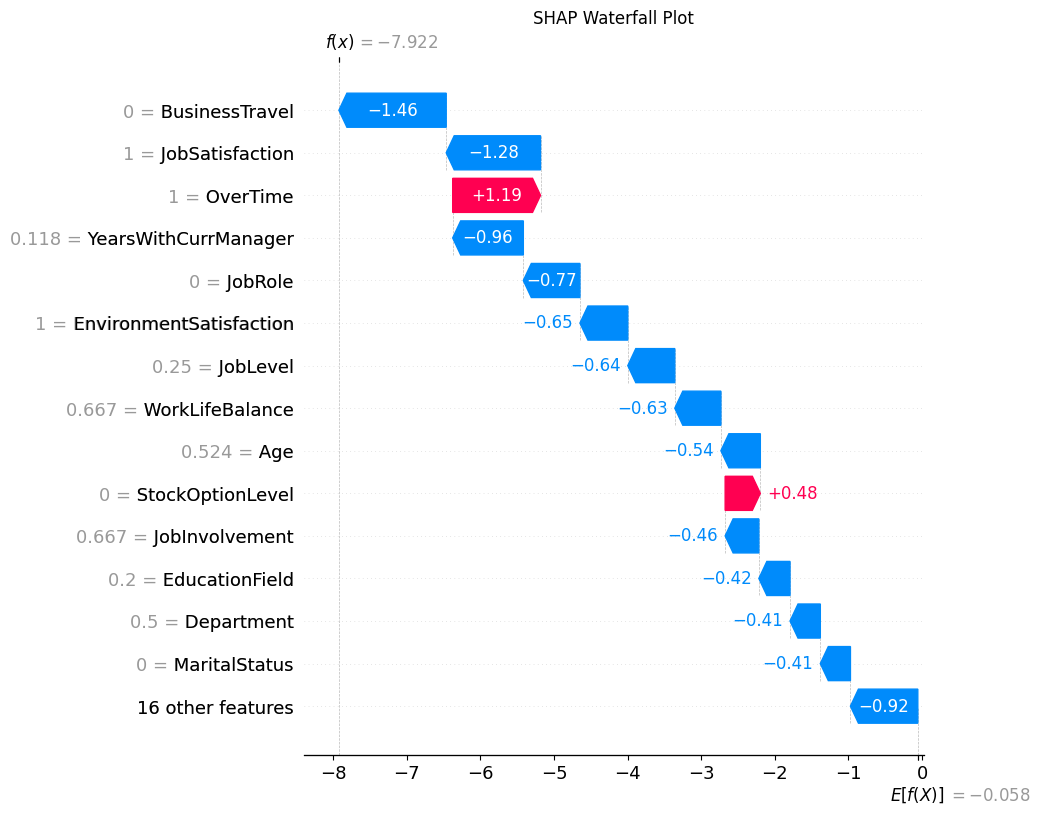


Generating SHAP Force Plot...


<Figure size 1600x400 with 0 Axes>

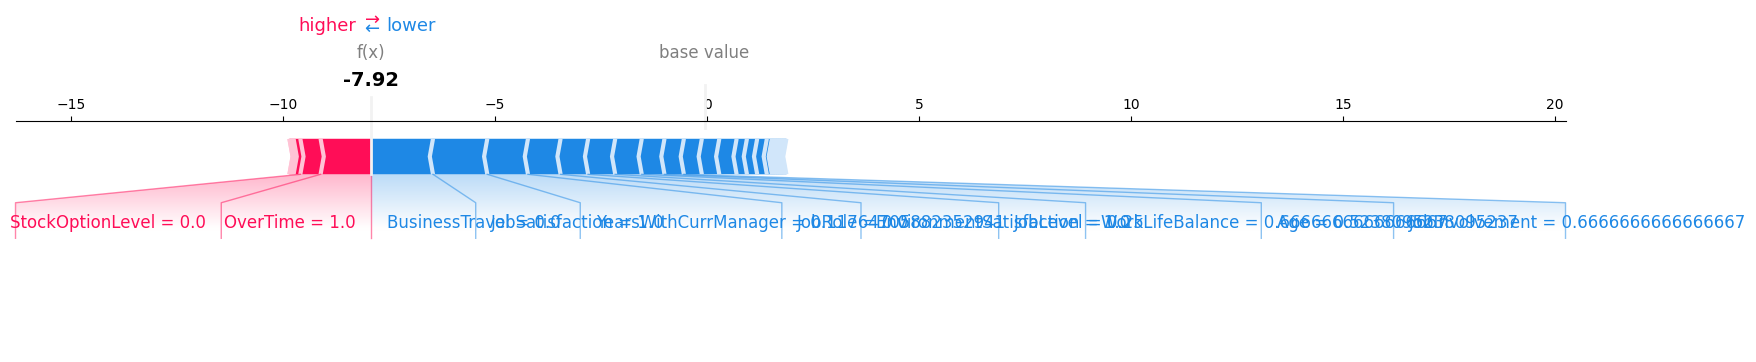


================ PERMUTATION IMPORTANCE ================


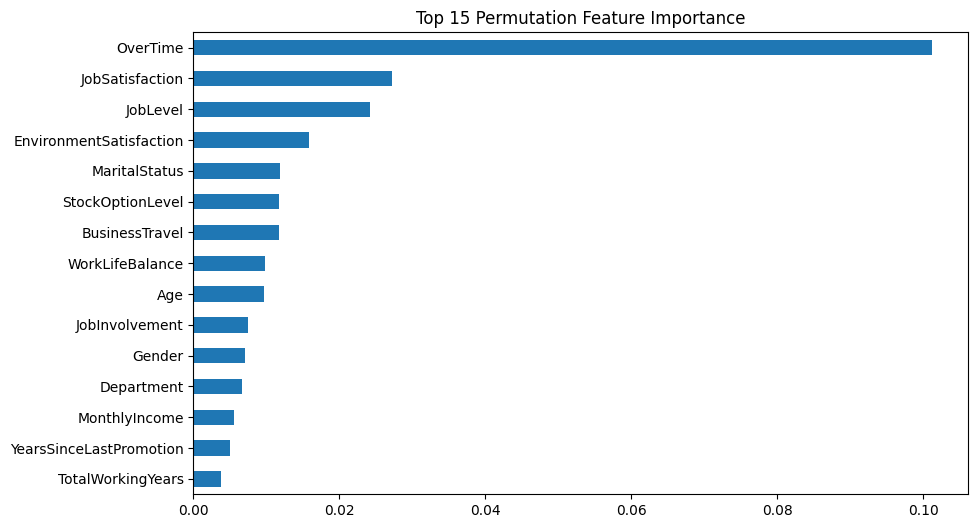


✅ All SHAP visualizations generated and saved successfully.


In [ ]:
# ============================================================
# 📦 INSTALL & IMPORT LIBRARIES
# ============================================================

_pip_install("shap")

import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

cat_model = joblib.load("base_catboost_fullmodel.joblib")

# ============================================================
# PREPARE DATA
# ============================================================

X_test_array = np.array(X_test_final)
y_test_array = np.array(y_test_final)

feature_names = X.columns.tolist()

# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================

print("\n================ SHAP EXPLANATION ================")

explainer = shap.TreeExplainer(cat_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_array)

# ============================================================
# SAMPLE INDEX FOR LOCAL EXPLANATION
# ============================================================

sample_index = 5

# ============================================================
# 1️⃣ SHAP BAR PLOT
# ============================================================

print("\nGenerating SHAP Bar Plot...")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_array,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance (Bar Plot)")

plt.savefig(
    "shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 2️⃣ SHAP BEESWARM PLOT
# ============================================================

print("\nGenerating SHAP Beeswarm Plot...")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_array,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Beeswarm Plot")

plt.savefig(
    "shap_beeswarm_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 3️⃣ SHAP WATERFALL PLOT
# ============================================================

print("\nGenerating SHAP Waterfall Plot...")

shap_exp = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test_array[sample_index],
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))

shap.plots.waterfall(
    shap_exp,
    max_display=15,
    show=False
)

plt.title("SHAP Waterfall Plot")

plt.savefig(
    "shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 4️⃣ SHAP FORCE PLOT
# ============================================================

print("\nGenerating SHAP Force Plot...")

plt.figure(figsize=(16, 4))

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_array[sample_index],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)

plt.savefig(
    "shap_force_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 5️⃣ PERMUTATION IMPORTANCE
# ============================================================

print("\n================ PERMUTATION IMPORTANCE ================")

perm_result = permutation_importance(
    cat_model,
    X_test_array,
    y_test_array,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

perm_importance.head(15).plot(kind="barh")

plt.title("Top 15 Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.savefig(
    "permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ All SHAP visualizations generated and saved successfully.")


================ SHAP EXPLANATION ================

Generating SHAP Global Summary Plot...


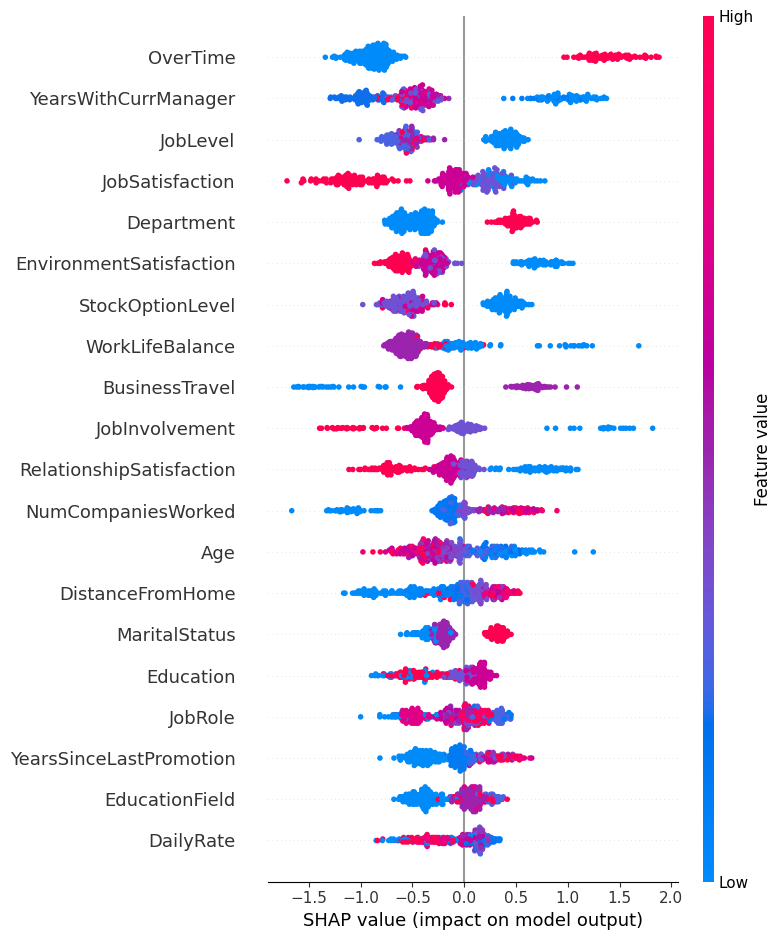


Generating SHAP Local Explanation for One Employee...


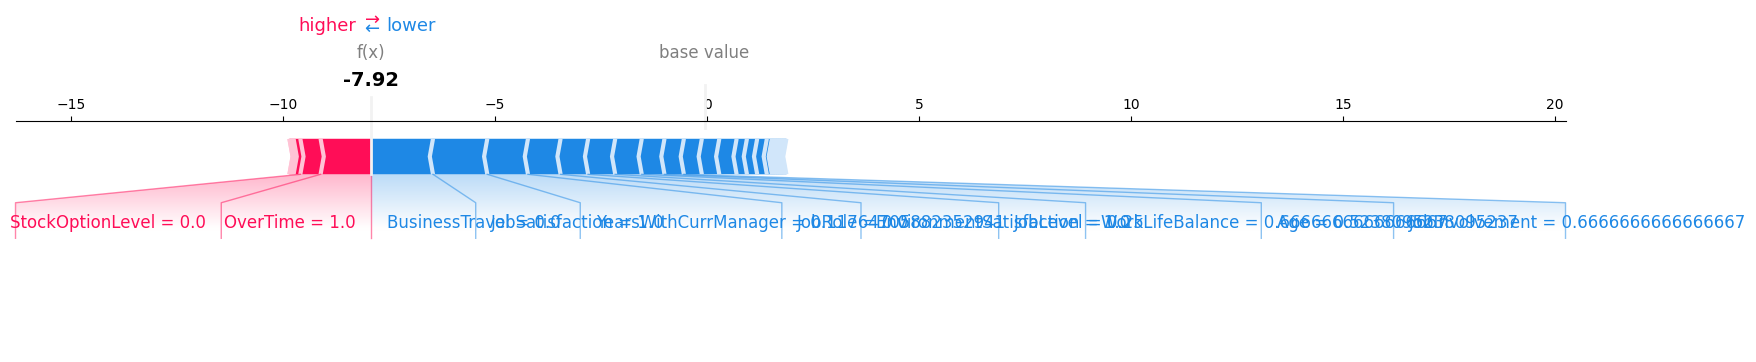


================ PERMUTATION IMPORTANCE ================

Top 15 Features by Permutation Importance:
OverTime                   0.101124
JobSatisfaction            0.027179
JobLevel                   0.024184
EnvironmentSatisfaction    0.015836
MaritalStatus              0.011815
StockOptionLevel           0.011738
BusinessTravel             0.011700
WorkLifeBalance            0.009824
Age                        0.009632
JobInvolvement             0.007487
Gender                     0.006999
Department                 0.006686
MonthlyIncome              0.005513
YearsSinceLastPromotion    0.004981
TotalWorkingYears          0.003774
dtype: float64


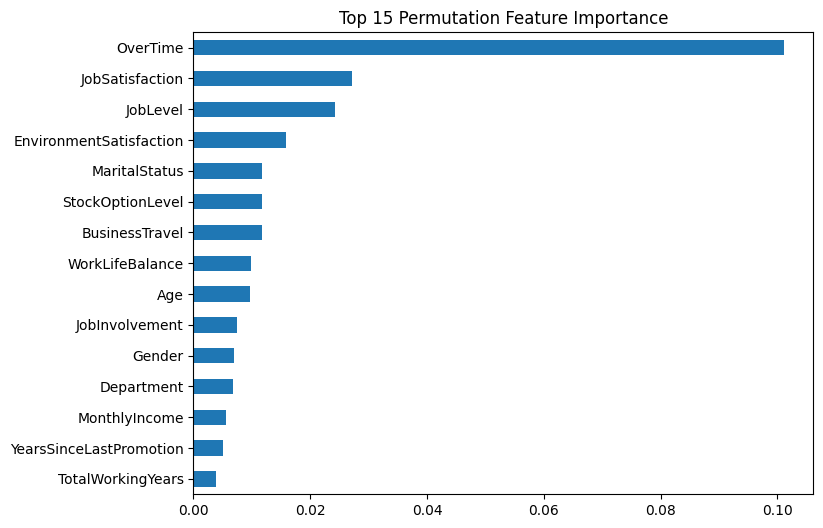


================ META-LEARNER COEFFICIENTS ================

Base Model Contribution in Stacking Ensemble:
svm         4.031494
etc         2.793271
catboost    2.382399
rf          1.569370
dtype: float64


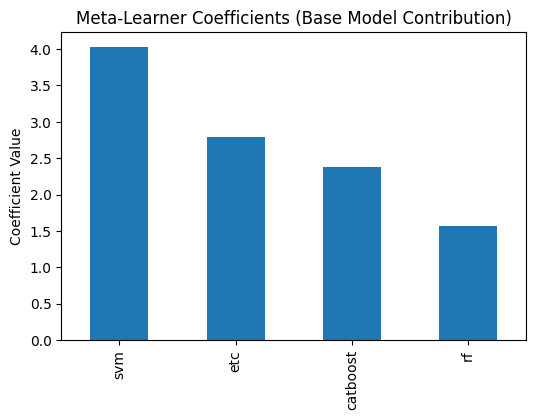


✅ XAI Analysis Complete.


In [ ]:
# ============================================================
# 📦 Install Required Libraries
# ============================================================
_pip_install("shap")

import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Ensure numpy array format
X_test_array = np.array(X_test_final)
y_test_array = np.array(y_test_final)

# ============================================================
# 1️⃣ SHAP EXPLANATION (Using CatBoost Base Model)
# ============================================================

print("\n================ SHAP EXPLANATION ================")

# Load trained CatBoost model
cat_model = joblib.load("base_catboost_fullmodel.joblib")

# Create SHAP explainer
explainer = shap.TreeExplainer(cat_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_array)

# ---------------------------
# 🔹 Global SHAP Explanation
# ---------------------------
print("\nGenerating SHAP Global Summary Plot...")

shap.summary_plot(
    shap_values,
    X_test_array,
    feature_names=X.columns
)

# ---------------------------
# 🔹 Local SHAP Explanation
# ---------------------------
print("\nGenerating SHAP Local Explanation for One Employee...")

sample_index = 5  # change index if needed

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_array[sample_index],
    feature_names=X.columns,
    matplotlib=True
)

# ============================================================
# 2️⃣ PERMUTATION IMPORTANCE (Validation)
# ============================================================

print("\n================ PERMUTATION IMPORTANCE ================")

perm_result = permutation_importance(
    cat_model,
    X_test_array,
    y_test_array,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 15 Features by Permutation Importance:")
print(perm_importance.head(15))

# Plot Permutation Importance
plt.figure(figsize=(8,6))
perm_importance.head(15).plot(kind="barh")
plt.title("Top 15 Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# ============================================================
# 3️⃣ META-LEARNER COEFFICIENT ANALYSIS
# ============================================================

print("\n================ META-LEARNER COEFFICIENTS ================")

meta_model = joblib.load("stack_meta_logistic.joblib")

base_model_names = ["catboost", "svm", "rf", "etc"]

meta_coefficients = pd.Series(
    meta_model.coef_[0],
    index=base_model_names
).sort_values(ascending=False)

print("\nBase Model Contribution in Stacking Ensemble:")
print(meta_coefficients)

# Plot Meta Model Coefficients
plt.figure(figsize=(6,4))
meta_coefficients.plot(kind="bar")
plt.title("Meta-Learner Coefficients (Base Model Contribution)")
plt.ylabel("Coefficient Value")
plt.show()

print("\n✅ XAI Analysis Complete.")


================ PERMUTATION IMPORTANCE ================

Top 15 Features by Permutation Importance:
TotalWorkingYears          0.003774
YearsSinceLastPromotion    0.004981
MonthlyIncome              0.005513
Department                 0.006686
Gender                     0.006999
JobInvolvement             0.007487
Age                        0.009632
WorkLifeBalance            0.009824
BusinessTravel             0.011700
StockOptionLevel           0.011738
MaritalStatus              0.011815
EnvironmentSatisfaction    0.015836
JobLevel                   0.024184
JobSatisfaction            0.027179
OverTime                   0.101124
dtype: float64


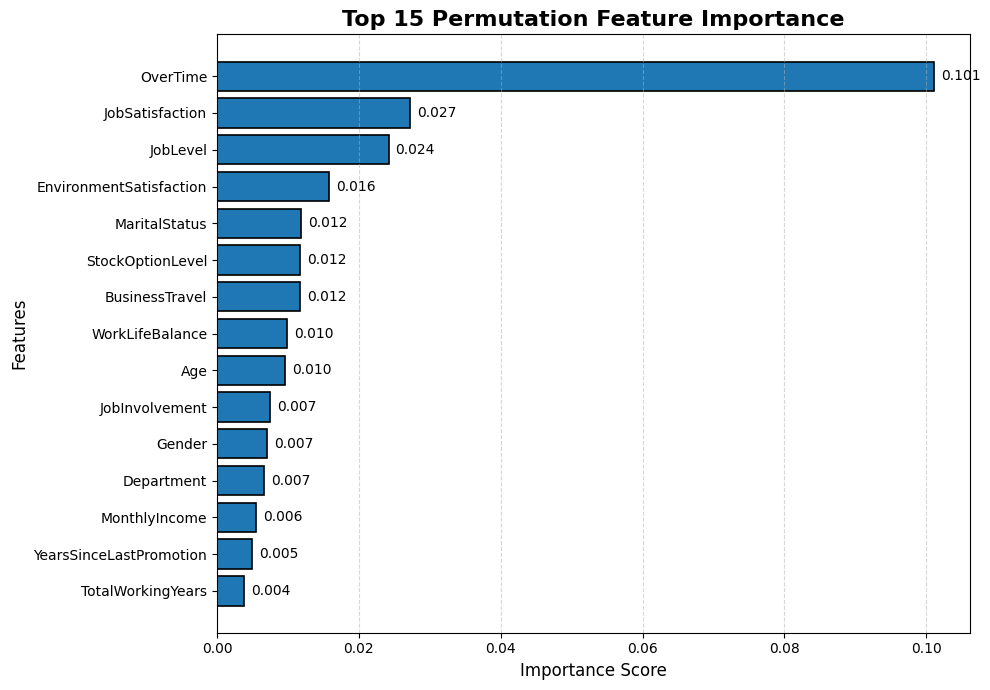

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance

# ============================================================
# 2️⃣ PERMUTATION IMPORTANCE (Validation)
# ============================================================

print("\n================ PERMUTATION IMPORTANCE ================")

perm_result = permutation_importance(
    cat_model,
    X_test_array,
    y_test_array,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# Create importance dataframe
perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=True)

print("\nTop 15 Features by Permutation Importance:")
print(perm_importance.tail(15))

# Select Top 15
top15 = perm_importance.tail(15)

# ============================================================
# 🎨 BEAUTIFUL PLOT
# ============================================================

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top15.index,
    top15.values,
    edgecolor='black',
    linewidth=1.2
)

# Add values beside bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=10
    )

# Titles and labels
plt.title(
    "Top 15 Permutation Feature Importance",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Importance Score",
    fontsize=12
)

plt.ylabel(
    "Features",
    fontsize=12
)

# Grid for better look
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Better spacing
plt.tight_layout()

# ============================================================
# 💾 SAVE GRAPH
# ============================================================

plt.savefig(
    "permutation_importance.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()